# Getting Started with spectroxide

Quick-start tour of the two solver modes:

- **Green's function** (`method="greens_function"`) --- pure-Python, vectorized, evaluates in milliseconds. 2-5% accurate in the deep $\mu$- and $y$-eras.
- **PDE** (`method="pde"`) --- full Kompaneets + DC + BR evolution via the Rust binary. Reference accuracy; takes ~5-20 s per solve.

Walks through distortion shapes, single-burst injection, parallel parameter sweeps, intensity conversion, and cosmology presets.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from spectroxide import (
    solve, run_sweep, SolverResult, Cosmology,
    apply_style,
    mu_shape, y_shape, g_bb,
    delta_n_to_delta_I,
    j_bb_star, j_mu, j_y,
)

apply_style()

## 1. Distortion shapes

Energy injection at different epochs leaves different spectral signatures:

- **$\mu$-distortion** $M(x)$ — Bose-Einstein with chemical potential. Compton scattering equilibrates the photon temperature but cannot change photon number; injected energy goes into a chemical potential.
- **$y$-distortion** $Y_{SZ}(x)$ — frequency redistribution without thermalization. Late-time injection ($z \lesssim 5\times 10^4$).
- **Temperature shift** $G_{bb}(x) = x\,n_{pl}(1+n_{pl})$ — degenerate with $T_{CMB}$ and unobservable.

Here $x = h\nu / (k_B T_z)$.


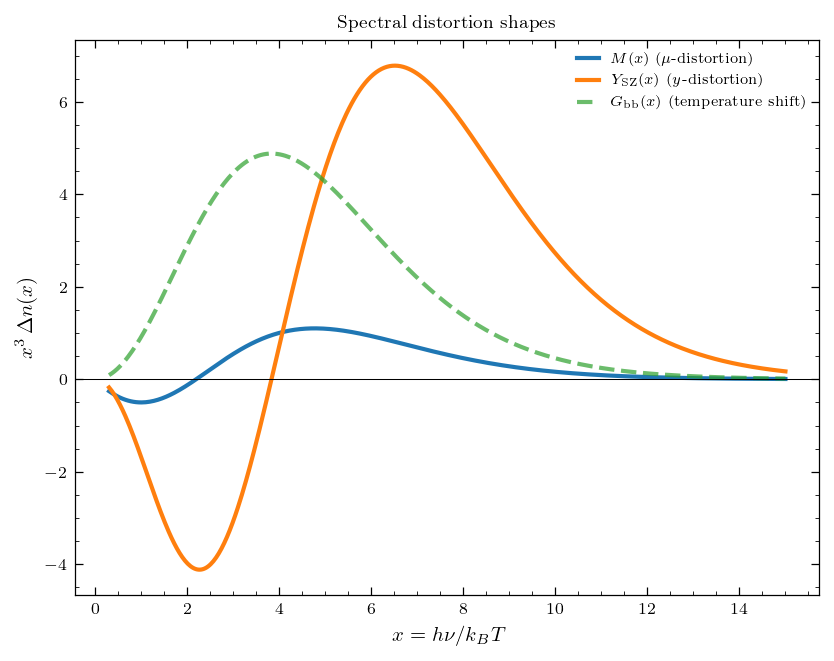

In [2]:
x = np.linspace(0.3, 15, 500)

fig, ax = plt.subplots()
ax.plot(x, x**3 * mu_shape(x), label=r'$M(x)$ ($\mu$-distortion)', lw=2)
ax.plot(x, x**3 * y_shape(x), label=r'$Y_{\rm SZ}(x)$ ($y$-distortion)', lw=2)
ax.plot(x, x**3 * g_bb(x), label=r'$G_{\rm bb}(x)$ (temperature shift)', lw=2, ls='--', alpha=0.7)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(r'$x = h\nu / k_B T$')
ax.set_ylabel(r'$x^3 \, \Delta n(x)$')
ax.set_title('Spectral distortion shapes')
ax.legend()
plt.show()


## 2. Green's function mode

The Chluba (2013) Green's function decomposes a single-burst injection into $\mu$, $y$, and a residual. Pure Python, vectorized, evaluates in milliseconds.

Use `method="greens_function"` for parameter scans where 2–5% accuracy is acceptable.


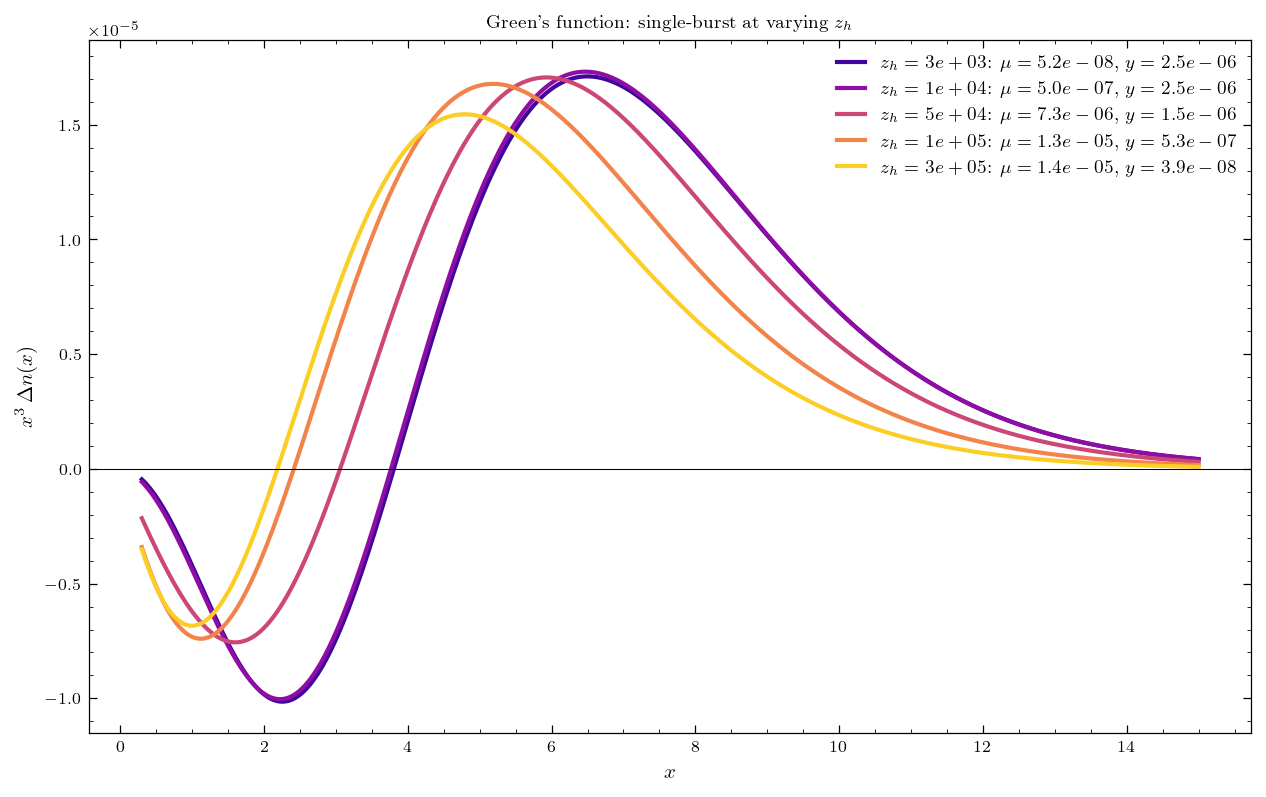

In [3]:
redshifts = [3e3, 1e4, 5e4, 1e5, 3e5]
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(redshifts)))

fig, ax = plt.subplots(figsize=(10, 6))
for z_h, c in zip(redshifts, colors):
    r = solve(method="greens_function", z_h=z_h, delta_rho=1e-5, x=x)
    ax.plot(x, x**3 * r.delta_n, color=c, lw=2,
            label=fr'$z_h = {z_h:.0e}$: $\mu = {r.mu:.1e}$, $y = {r.y:.1e}$')

ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$x^3 \, \Delta n(x)$')
ax.set_title("Green's function: single-burst at varying $z_h$")
ax.legend(fontsize=9)
plt.show()


## 3. PDE solver mode

The PDE solver evolves the full photon occupation number $n(x,z)$ through the coupled Kompaneets + DC + BR equations. Captures the $\mu$–$y$ transition and small nonlinear corrections that the Green's function misses.

Pass `injection={'type': 'single_burst', 'z_h': ..., 'sigma_z': ...}` and the top-level `delta_rho`. A single PDE solve takes ~5–20 s.


mu = 1.3901e-05
y  = 6.3760e-07
Delta(rho)/rho = 9.9698e-06
method = pde
x grid: 4000 points, x in [0.000, 60.0]


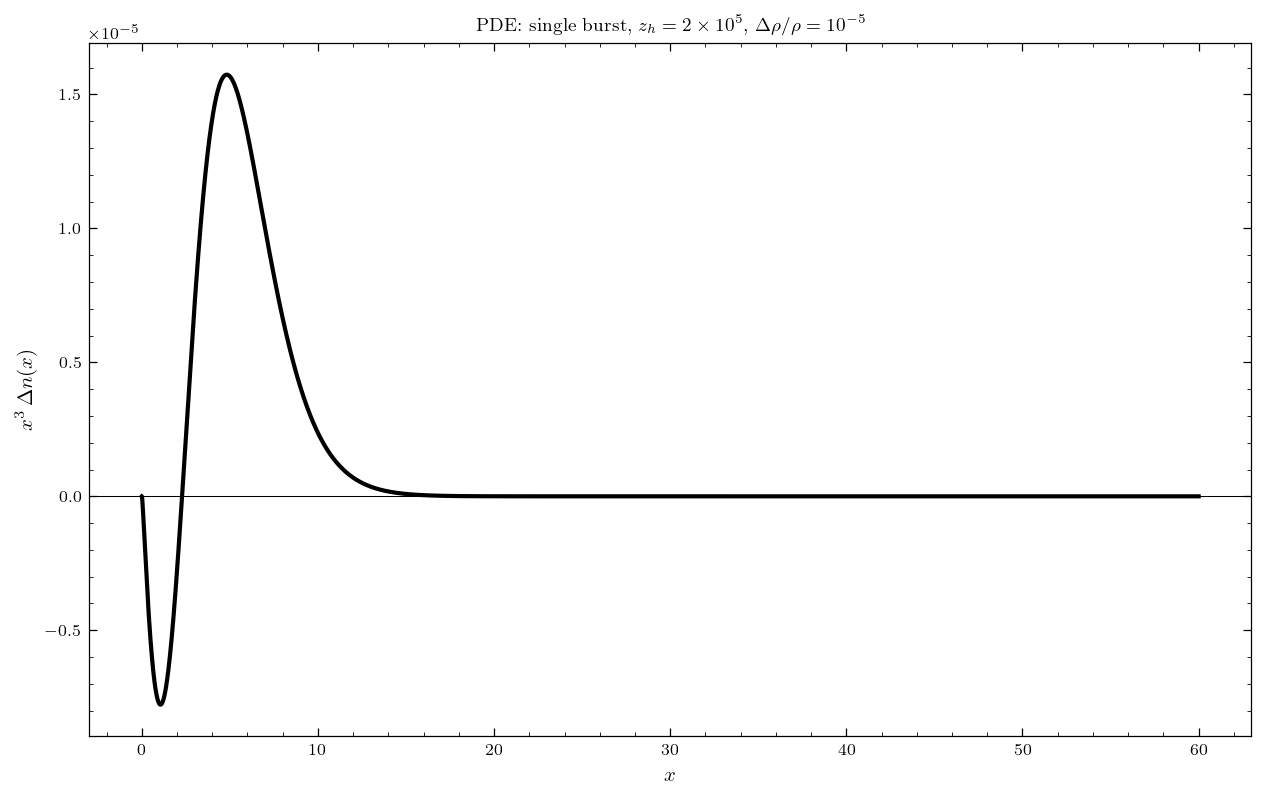

In [4]:
result = solve(
    injection={'type': 'single_burst', 'z_h': 2e5, 'sigma_z': 5000},
    delta_rho=1e-5,
    z_start=3e5,
    z_end=1e3,
)

print(f"mu = {result.mu:.4e}")
print(f"y  = {result.y:.4e}")
print(f"Delta(rho)/rho = {result.delta_rho_over_rho:.4e}")
print(f"method = {result.method}")
print(f"x grid: {len(result.x)} points, x in [{result.x.min():.3f}, {result.x.max():.1f}]")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(result.x, result.x**3 * result.delta_n, 'k-', lw=2)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$x^3 \, \Delta n(x)$')
ax.set_title(rf'PDE: single burst, $z_h = 2\times 10^5$, $\Delta\rho/\rho = 10^{{-5}}$')
plt.show()


## 4. Parallel sweeps with `run_sweep`

`solve()` runs one PDE at a time. For parameter scans (many $z_h$ values), call `run_sweep()` directly: the entire $z_h$ list is shipped to the Rust binary, which fans out across CPU cores. By default all available cores are used; pass `n_threads=N` to cap.

The return is a dict with a `results` list — one entry per injection redshift carrying `pde_mu`, `pde_y`, `drho`, `x`, `delta_n`.


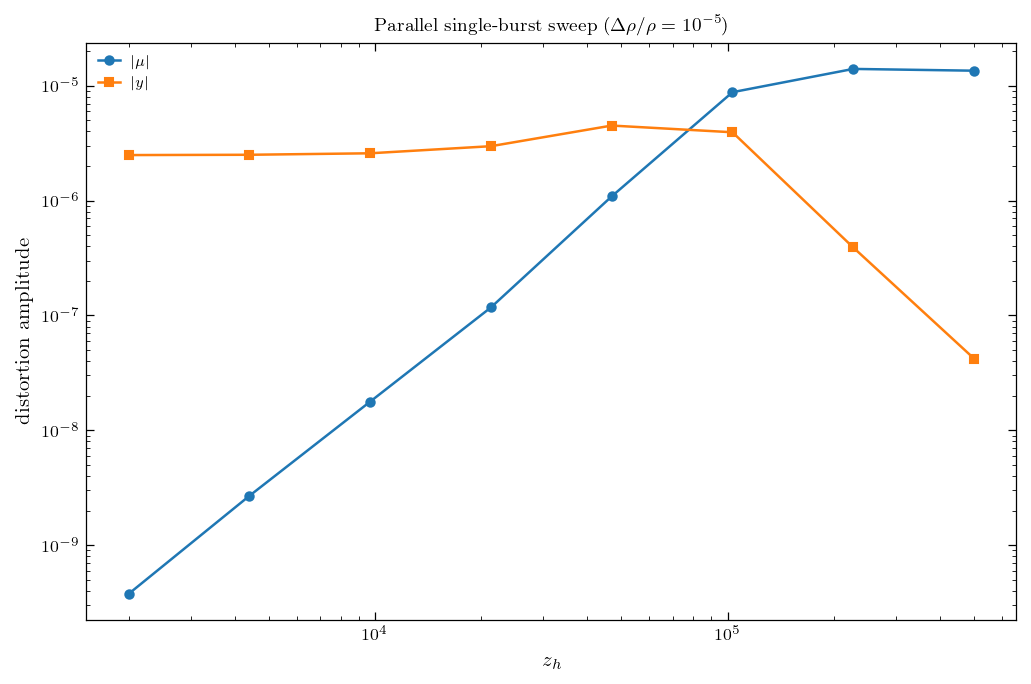

In [5]:
z_h_grid = np.logspace(np.log10(2e3), np.log10(5e5), 8)

sweep = run_sweep(
    z_injections=z_h_grid.tolist(),
    delta_rho=1e-5,
    z_end=1e3,
)

mu_pde = np.array([r['pde_mu'] for r in sweep['results']])
y_pde  = np.array([r['pde_y']  for r in sweep['results']])

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(z_h_grid, np.abs(mu_pde), 'o-', label=r'$|\mu|$')
ax.loglog(z_h_grid, np.abs(y_pde),  's-', label=r'$|y|$')
ax.set_xlabel(r'$z_h$')
ax.set_ylabel(r'distortion amplitude')
ax.set_title(r'Parallel single-burst sweep ($\Delta\rho/\rho = 10^{-5}$)')
ax.legend()
plt.show()


## 5. PDE vs Green's function

The two modes agree to 2–5% in the deep $\mu$- and $y$-eras. In the transition region ($z_h \sim 5\times 10^4$) the PDE is more accurate because the Green's function decomposes onto fixed shapes that don't fully capture intermediate spectra.


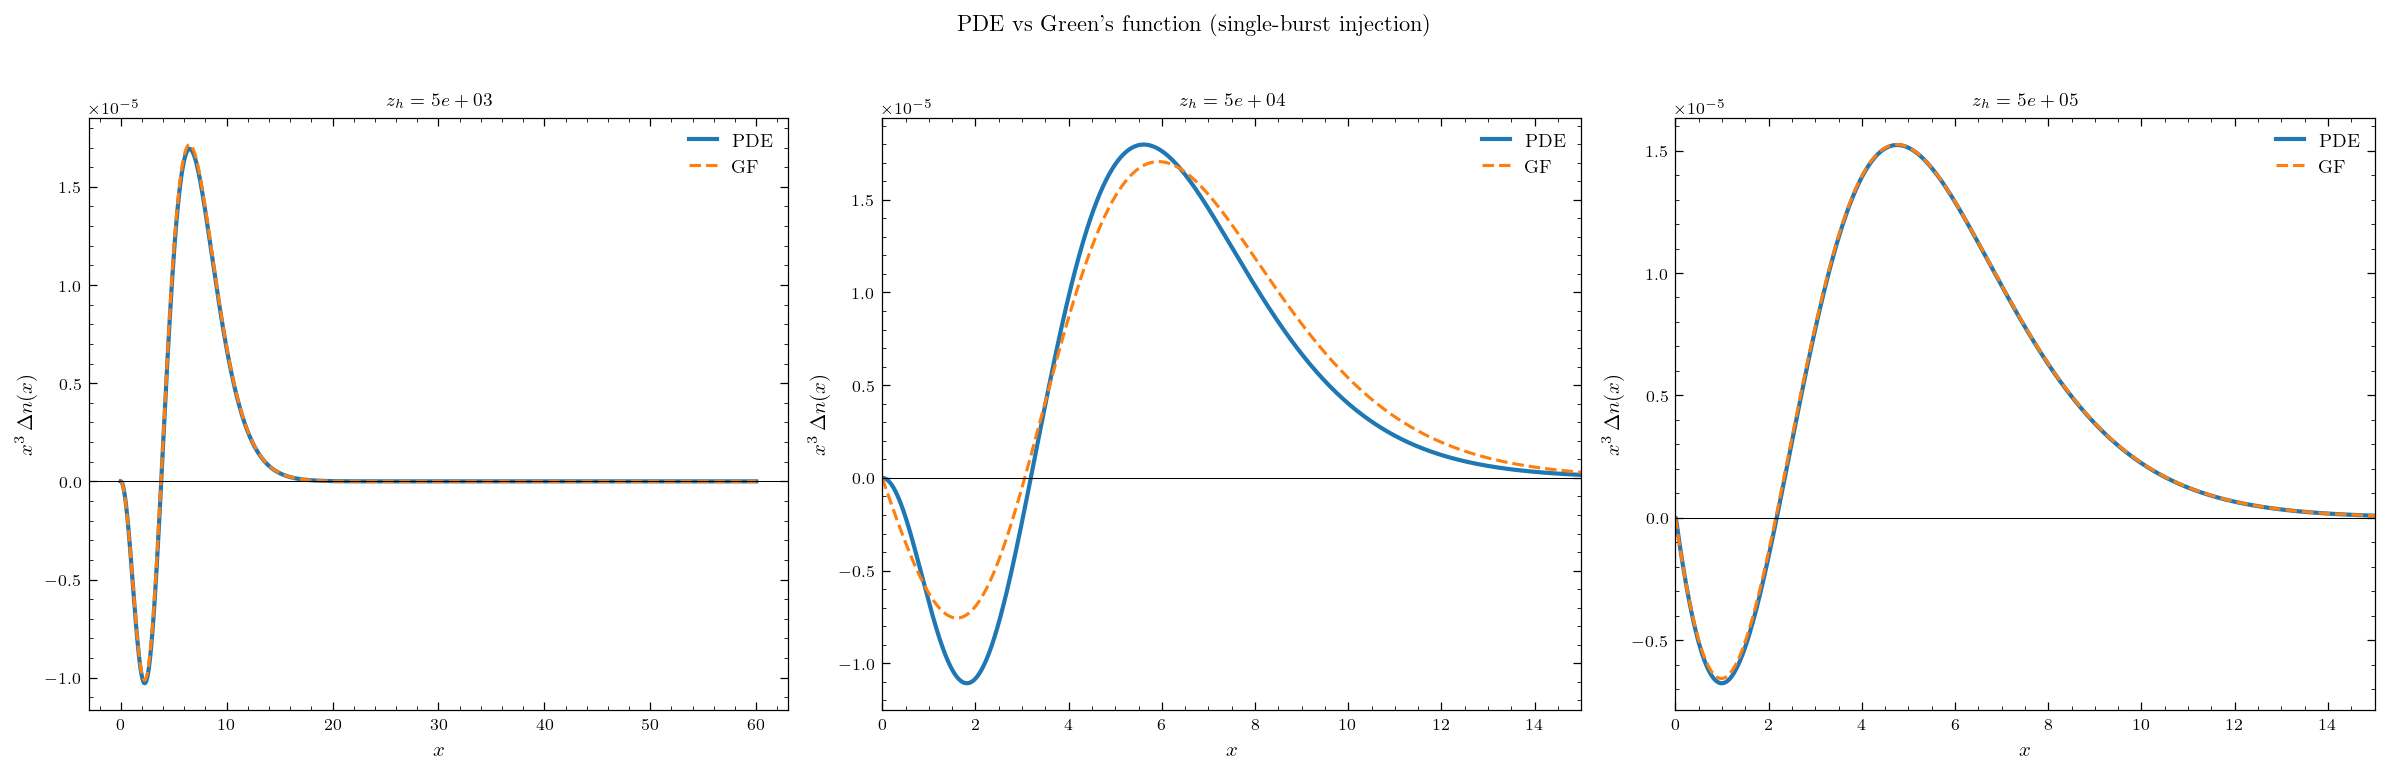

In [6]:
z_injections = [5e3, 5e4, 5e5]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, z_h in zip(axes.flat, z_injections):
    sigma_z = max(z_h * 0.04, 100)
    z_start = z_h + 7 * sigma_z

    pde = solve(
        injection={'type': 'single_burst', 'z_h': z_h, 'sigma_z': sigma_z},
        delta_rho=1e-5,
        z_start=z_start, z_end=1e3,
    )
    gf = solve(method="greens_function", z_h=z_h, delta_rho=1e-5, x=pde.x)

    ax.plot(pde.x, pde.x**3 * pde.delta_n, 'C0-', lw=2, label='PDE')
    ax.plot(gf.x, gf.x**3 * gf.delta_n, 'C1--', lw=1.5, label="GF")
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$x^3 \, \Delta n(x)$')
    ax.set_title(rf'$z_h = {z_h:.0e}$')
    ax.legend(fontsize=9)
    if z_h > 1e4:
        ax.set_xlim(0, 15)

plt.suptitle('PDE vs Green\'s function (single-burst injection)', y=1.02)
plt.tight_layout()
plt.show()


## 6. Intensity

Convert $\Delta n(x)$ to physical intensity $\Delta I_\nu$ in Jy/sr via the `delta_I` property on `SolverResult`. Useful for plotting against FIRAS/PIXIE bands.


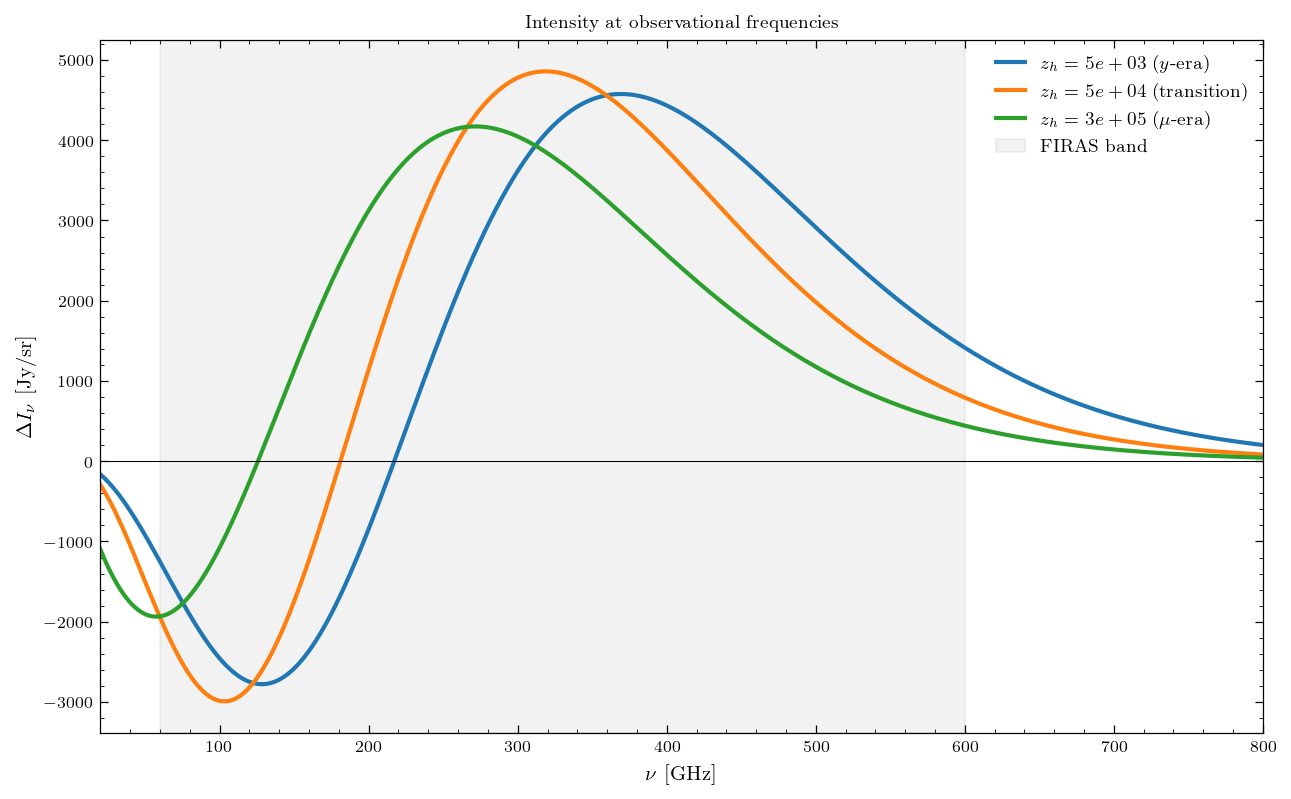

In [7]:
scenarios = [
    (5e3, '$y$-era'),
    (5e4, 'transition'),
    (3e5, '$\\mu$-era'),
]

fig, ax = plt.subplots(figsize=(10, 6))
for (z_h, label), c in zip(scenarios, ['C0', 'C1', 'C2']):
    sigma_z = max(z_h * 0.04, 100)
    r = solve(
        injection={'type': 'single_burst', 'z_h': z_h, 'sigma_z': sigma_z},
        delta_rho=1e-5,
        z_start=z_h + 7 * sigma_z, z_end=1e3,
    )
    nu_ghz, dI_jy = r.delta_I
    ax.plot(nu_ghz, dI_jy, color=c, lw=2, label=f'$z_h = {z_h:.0e}$ ({label})')

ax.axhline(0, color='k', lw=0.5)
ax.axvspan(60, 600, alpha=0.1, color='gray', label='FIRAS band')
ax.set_xlabel(r'$\nu$ [GHz]')
ax.set_ylabel(r'$\Delta I_\nu$ [Jy/sr]')
ax.set_xlim(20, 800)
ax.set_title('Intensity at observational frequencies')
ax.legend(fontsize=9)
plt.show()


## 7. Cosmology

Pass a `Cosmology` dataclass (or dict) via `cosmo=...`. Defaults are the Chluba 2013 values ($h=0.71$, $\Omega_b=0.044$, $\Omega_m=0.26$). Presets `Cosmology.planck2015()` and `Cosmology.planck2018()` are available.


In [8]:
default = Cosmology.default()
planck = Cosmology.planck2018()
print(f"default: h={default.h}, Omega_b={default.omega_b}, Omega_m={default.omega_m}")
print(f"Planck 2018: h={planck.h}, Omega_b={planck.omega_b}, Omega_m={planck.omega_m}")

r_default = solve(method="greens_function", z_h=2e5, delta_rho=1e-5, cosmo=default)
r_planck = solve(method="greens_function", z_h=2e5, delta_rho=1e-5, cosmo=planck)
print(f"\nmu (default cosmo)   = {r_default.mu:.4e}")
print(f"mu (Planck18 cosmo)  = {r_planck.mu:.4e}")
print(f"relative diff        = {(r_planck.mu - r_default.mu)/r_default.mu * 100:.2f}%")


default: h=0.71, Omega_b=0.044, Omega_m=0.26
Planck 2018: h=0.6736, Omega_b=0.0493, Omega_m=0.3153

mu (default cosmo)   = 1.3721e-05
mu (Planck18 cosmo)  = 1.3721e-05
relative diff        = 0.00%


## Summary

| Mode | Speed | Accuracy | Use when |
|------|-------|----------|----------|
| `method="greens_function"` | ms | 2–5% (μ/y eras), 8–13% (transition) | Parameter scans, quick estimates |
| `method="pde"` | 5–20 s | reference | Single accurate spectrum, transition region, photon injection |
| `method="table"` | ms (after build) | PDE-level | Many evaluations, custom heating histories |

Next:
- **02 Energy injection** — built-in scenarios (decaying particles, dark matter)
- **03 New physics** — dark photon, monochromatic photon injection
- **04 Custom scenarios** — user-defined `dq_dz` and photon sources
- **05 Observational constraints** — FIRAS limits and full-spectrum fitting
- **06 Green's function tables** — PDE-accurate interpolation at GF speed
